In [2]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import kibble_zurek as kz
from itertools import combinations
from collections import Counter
import adprox

In [27]:
taus = np.logspace(-3,3,200)
L = 50
states = [state(L,tau,tau) for tau in taus]

[]

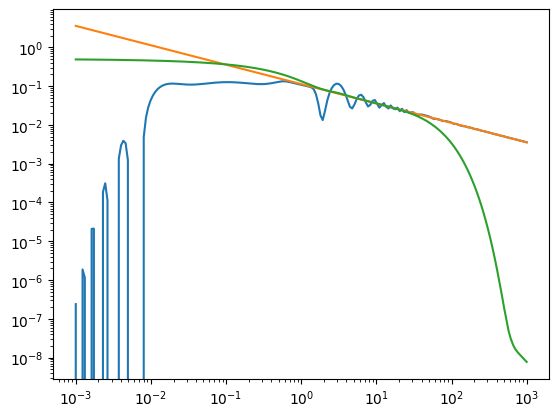

In [28]:
approx_result = array([1/2-adprox.sigma_general([0,1],tau)/2 for tau in taus])
analytical_result = array([1/2-sigmax([0,1],s)/2 for s in states])
expected_result = 1/2/pi/sqrt(2*taus)
plot(taus,approx_result)
plot(taus,expected_result)
plot(taus,analytical_result)
loglog()

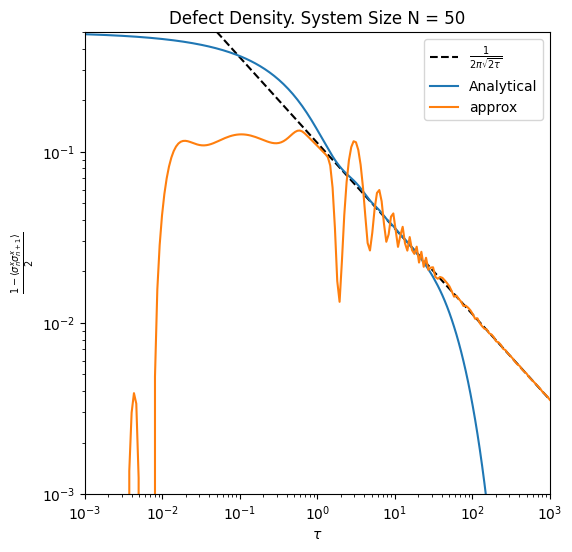

In [29]:
plt.figure(figsize=(6,6))
plot(taus,expected_result,"--k",label=r"$\frac{1}{2 \pi \sqrt{2\tau}}$")
plot(taus,analytical_result,label="Analytical")
plot(taus,approx_result,label="approx")

#plot(taus,1/2-BA/2,label=r"Large $\tau$ approximation")
xlim(taus[0],taus[-1])
ylim(.001,1/2)
legend()
title(fr"Defect Density. System Size N = {L}")
loglog()
xscale("log")
xlabel(r"$\tau$")
ylabel(r"$\frac{1-\langle \sigma^x_n \sigma^x_{n+1} \rangle}{2}$")
plt.savefig("figures/Convergence_of_Approximation.png")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/adiabatic_approx_func.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  exp1 = np.exp((2j)/v - (r**2 * v * (np.pi - 1j*np.log(v))) / (4 * np.log(v)**2))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/analytical_adiabatic_theory breakdown/adiabatic_approx_func.py:20: RuntimeWarning: invalid value encountered in scalar divide
  exp1 = np.exp((2j)/v - (r**2 * v * (np.pi - 1j*np.log(v))) / (4 * np.log(v)**2))
/Users/kristianmunnikhuis/Desktop/s

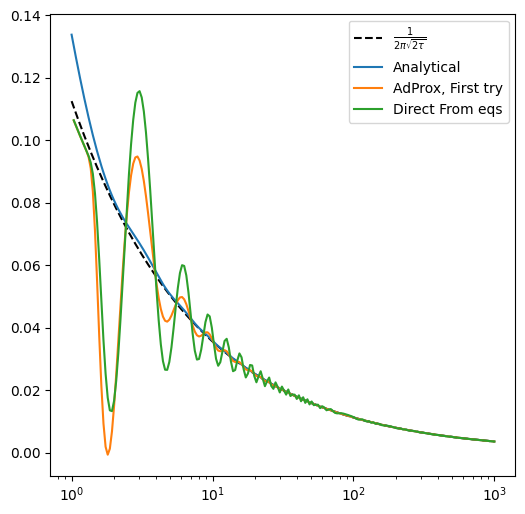

In [149]:
plt.figure(figsize=(6,6))
plot(taus,expected_result,"--k",label=r"$\frac{1}{2 \pi \sqrt{2\tau}}$")
plot(taus,analytical_result,label="Analytical")
x= array([adprox.BA(1,tau) for tau in taus])
plot(taus,1/2-x/2,label="AdProx, First try")
plot(taus,1/2-BA/2,label="Direct From eqs")
legend()
xscale("log")

[]

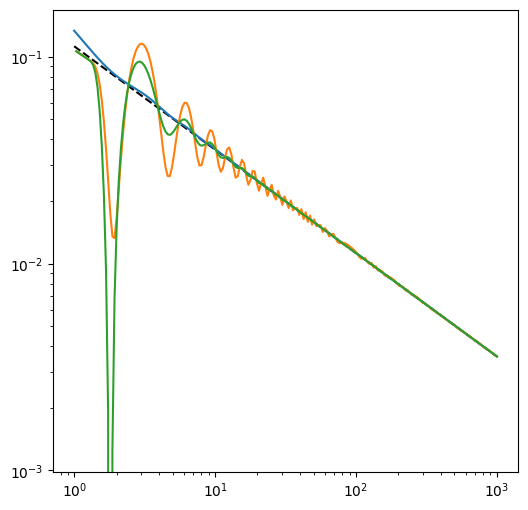

In [117]:
plt.figure(figsize=(6,6))
plot(taus,expected_result,"--k",label=r"$\frac{1}{2 \pi \sqrt{2\tau}}$")
plot(taus,analytical_result,label="Analytical")
plot(taus,1/2-BA/2,label=r"Large $\tau$ approximation")
plot(taus,x)
loglog()